In [1]:
import sys
import os
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from pycgp_finalclass.Config import CGPConfig
from pycgp_finalclass.ES import ES
from pycgp_finalclass.Evaluator import EvaluatorSin, Binary_Classifier, Regressor, MultiClassClassifier,Binary_Regressor
from pycgp_finalclass.Node import Node
from pycgp_finalclass.Mutation import Golden_mutation
from pycgp_finalclass.Function import Func
from pycgp_finalclass.Function_library import *
from pycgp_finalclass.Genome import CGPGenome


In [2]:
def build_funcLib(): #Define the function used
    return [Func(f_sum, 'sum', 2, 0),
            Func(safe_div, 'div', 2, 0),
            Func(f_aminus, 'aminus', 2, 0),
            Func(f_mult, 'mult', 2, 0),
            Func(f_exp, 'exp', 2, 0),
            Func(f_abs, 'abs', 1, 0),
            Func(f_sqrt, 'sqrt', 1, 0),
            Func(f_sqrtxy, 'sqrtxy', 2, 0),
            Func(f_squared, 'squared', 1, 0),
            Func(f_pow, 'pow', 2, 0),
            Func(f_one, 'one', 0, 0),
            Func(f_zero, 'zero', 0, 0),
            Func(f_const, 'const', 0, 1),
            Func(f_inv, 'inv', 1, 0),
            Func(f_gt, 'gt', 2, 0),
            #Func(f_asin, 'asin', 1, 0),
            #Func(f_acos, 'acos', 1, 0),
            #Func(f_atan, 'atan', 1, 0),
            #Func(f_sin, 'sin', 1, 0),
            Func(f_min, 'min', 2, 0),
            Func(f_max, 'max', 2, 0),
            Func(f_round, 'round', 1, 0),
            Func(f_floor, 'floor', 1, 0),
            Func(f_ceil, 'ceil', 1, 0)
            ]
functions = build_funcLib()

In [3]:




#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=1, num_nodes=30, num_outputs=1, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.1)

evaluator1 = EvaluatorSin()

#Test purpose
genome_cgp = CGPGenome.create_genome(CGP_config)
active_nodes = genome_cgp.get_active_nodes()
print("Active nodes:", active_nodes)



Active nodes: [<pycgp_finalclass.Node.Node object at 0x00000208025504A0>, <pycgp_finalclass.Node.Node object at 0x00000208025D7DA0>, <pycgp_finalclass.Node.Node object at 0x00000208025D7E00>]


In [4]:
#Initialise the ES and run the evolution
ES_cgp = ES(evaluator1, lam=4, parent_factory =lambda:CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden,config=CGP_config)
best_genome = ES_cgp.evolve(n_generations=10000, early_stopping=10000,early_switch=10000,verbose=True)

print(best_genome.to_function_string())


TypeError: 'float' object is not subscriptable

n1 = pow(x0, x0)
n2 = exp(x0, x0)
n3 = sqrtxy(n2, x0)
n4 = inv(n3)
n5 = squared(n3)
n6 = zero()
n7 = floor(n2)
n8 = sum(n7, n5)
n9 = floor(n8)
n10 = sum(x0, x0)
n11 = sqrt(n4)
n12 = one()
n13 = squared(x0)
n14 = sum(n8, x0)
n15 = const()
n16 = sqrtxy(x0, n14)
n17 = exp(n8, n5)
n18 = abs(n7)
n19 = zero()
n20 = zero()
n21 = max(n18, n3)
n22 = sum(n6, n4)
n23 = sum(n19, n19)
n24 = ceil(n3)
n25 = sqrt(n23)
n26 = squared(n16)
n27 = abs(x0)
n28 = zero()
n29 = aminus(n16, n10)
n30 = min(n15, n14)
Outputs: n30

Unrolled output expression 0:
min(const(), sum(sum(floor(exp(x0, x0)), squared(sqrtxy(exp(x0, x0), x0))), x0))



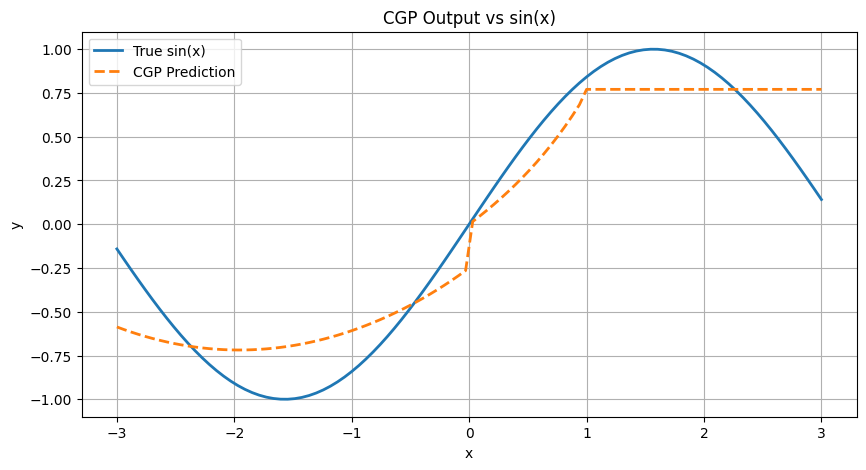

Fitness of best genome: 0.9020379656209007


In [5]:
#See if the output fit the sin function

import matplotlib.pyplot as plt

def plot_sin_vs_prediction(evaluator, genome):
    inputs = evaluator.inputs
    targets = evaluator.targets

    predictions = [genome.get_value([x])[0] for x in inputs]

    plt.figure(figsize=(10, 5))
    plt.plot(inputs, targets, label='True sin(x)', linewidth=2)
    plt.plot(inputs, predictions, label='CGP Prediction', linestyle='--', linewidth=2)
    plt.title('CGP Output vs sin(x)')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()
print(best_genome.to_function_string())
plot_sin_vs_prediction(evaluator1, best_genome)
print(f"Fitness of best genome: {evaluator1.evaluate(best_genome)}")


Starting fitness -7.6099


Gen 503 | Best: 0.6975: 100%|██████████| 1000/1000 [04:17<00:00,  3.88gen/s]


Best Train fitness achieved: 0.6975

Test fitness: 0.6689
n4 = sum(x2, x1)
n5 = const()
n6 = min(n4, x3)
n7 = floor(n6)
n8 = mult(n7, n6)
n9 = round(n8)
n10 = round(n4)
n11 = one()
n12 = inv(x1)
n13 = sum(n6, n6)
n14 = one()
n15 = ceil(n4)
n16 = aminus(n15, n13)
n17 = round(x1)
n18 = inv(x0)
n19 = exp(x3, n8)
n20 = mult(n4, n16)
n21 = sqrtxy(n4, n19)
n22 = sum(n21, n5)
n23 = abs(n11)
n24 = squared(x0)
n25 = min(x3, n20)
n26 = round(n20)
n27 = zero()
n28 = one()
n29 = mult(n20, n11)
n30 = sum(n22, n21)
n31 = gt(n9, n30)
n32 = pow(n7, n29)
n33 = abs(n23)
Outputs: n20, n30, n9, n9, n32, n31, n12, n7, n29

Unrolled output expression 0:
mult(sum(x2, x1), aminus(ceil(sum(x2, x1)), sum(min(sum(x2, x1), x3), min(sum(x2, x1), x3))))
Unrolled output expression 1:
sum(sum(sqrtxy(sum(x2, x1), exp(x3, mult(floor(min(sum(x2, x1), x3)), min(sum(x2, x1), x3)))), const()), sqrtxy(sum(x2, x1), exp(x3, mult(floor(min(sum(x2, x1), x3)), min(sum(x2, x1), x3)))))
Unrolled output expression 2:
round(mult(fl

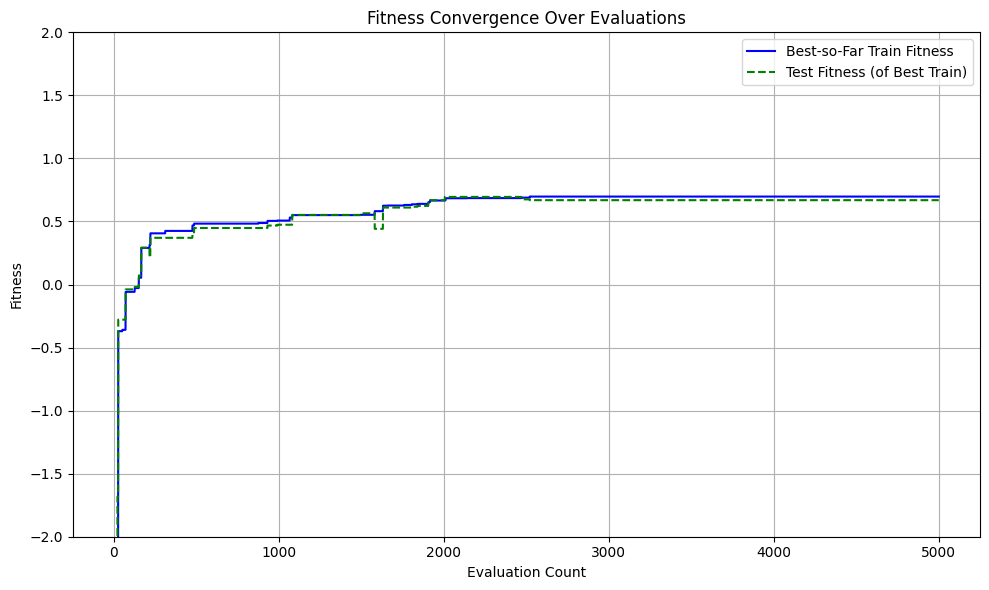

c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\pycgp_finalclass\Genome.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


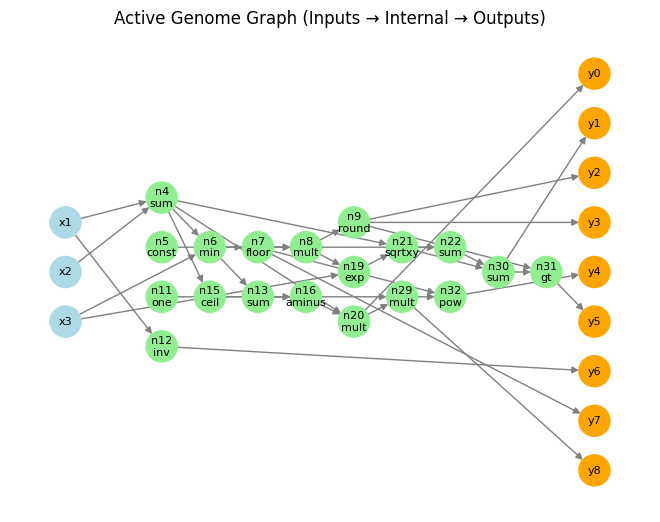

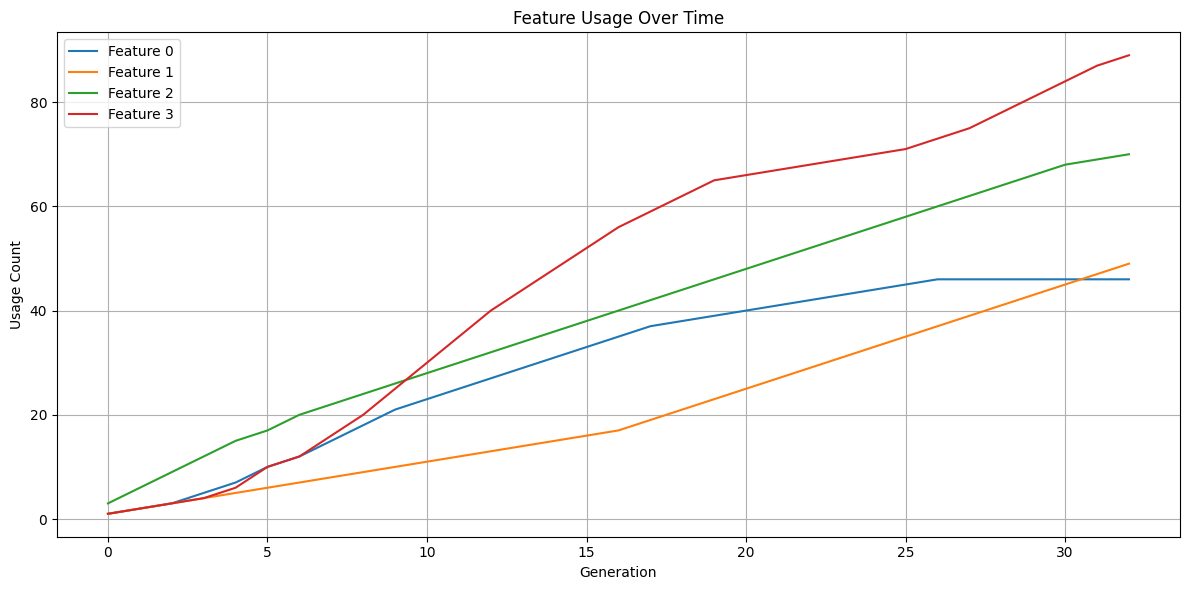

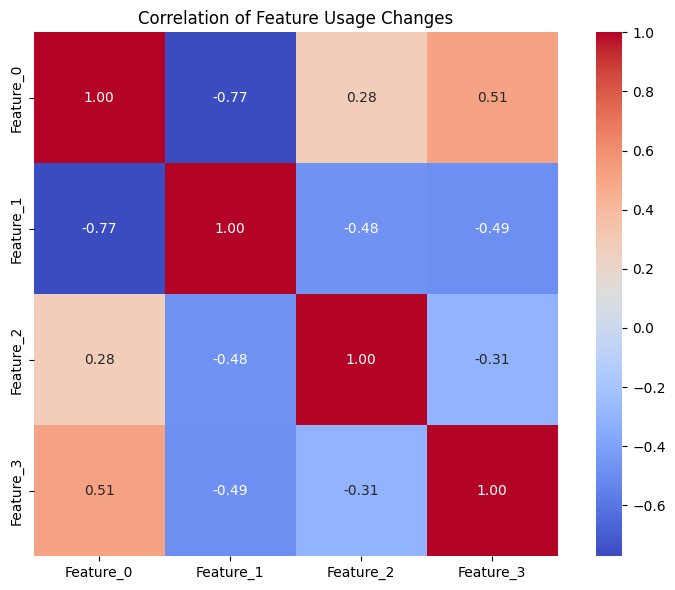

In [15]:
##WORK IN PROGRESS

from pmlb import fetch_data
from sklearn.preprocessing import MinMaxScaler

# Returns NumPy arrays
gametes = fetch_data('1027_ESL')
X, y = fetch_data('1027_ESL', return_X_y=True, local_cache_dir='./datasets')

# Conversion des colonnes en float
X = X.astype(float)
y = y.astype(float)

# Standardisation avec MinMaxScaler dans l'intervalle [-1, 1]
scaler = MinMaxScaler(feature_range=(-1, 1))
X = scaler.fit_transform(X)

evaluator2 = Regressor(X, y)

#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=9, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)
ES_cgp = ES(evaluator2, lam=5,parent_factory = lambda: CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden,config=CGP_config)
best_genome = ES_cgp.evolve(n_generations=1000, early_stopping=1000,early_switch=1000,verbose=True)



In [5]:
from pmlb import fetch_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import pandas as pd

# --- Load the dataset ---
X, y = fetch_data('1027_ESL', return_X_y=True, local_cache_dir='./datasets')

# --- Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Optional: Standardize features for models that benefit from it (SVM, KNN, Ridge, etc.) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Define regression models ---
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'KNN Regressor': KNeighborsRegressor()
}

# --- Evaluate R² for each model ---
results = {}

for name, model in models.items():
    if name in ['Support Vector Regressor', 'KNN Regressor', 'Ridge Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    results[name] = r2
    print(f"{name}: R² score = {r2:.4f}")

# --- Show sorted results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['R2 Score'])
df_results = df_results.sort_values('R2 Score', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)

print("\n=== CGP result ===")
print(f"CGP: R² score = {evaluator2.evaluate(best_genome)}")


Linear Regression: R² score = 0.8234
Ridge Regression: R² score = 0.8233
Random Forest: R² score = 0.7418
Gradient Boosting: R² score = 0.8038
Support Vector Regressor: R² score = 0.8075
KNN Regressor: R² score = 0.8001

=== Sorted Results ===
                          R2 Score
Linear Regression         0.823357
Ridge Regression          0.823297
Support Vector Regressor  0.807521
Gradient Boosting         0.803834
KNN Regressor             0.800066
Random Forest             0.741804

=== CGP result ===
CGP: R² score = 0.4612174604226005


In [21]:
##WORK IN PROGRESS

from pmlb import fetch_data
from sklearn.preprocessing import MinMaxScaler

# Returns NumPy arrays
gametes = fetch_data('car_evaluation')
X, y = fetch_data('car_evaluation', return_X_y=True, local_cache_dir='./datasets')

# Conversion des colonnes en float
X = X.astype(float)
y = y.astype(float)


# Standardisation avec MinMaxScaler dans l'intervalle [-1, 1]
scaler = MinMaxScaler(feature_range=(-1, 1))
X = scaler.fit_transform(X)

evaluator2 = MultiClassClassifier(X, y)

#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=4, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)
ES_cgp = ES(evaluator2, lam=5,parent_factory=lambda: CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden, config=CGP_config)
best_genome = ES_cgp.evolve(n_generations=1000, early_stopping=5000,early_switch=5000, verbose=True)



Starting fitness 0.5803


Gen 3 | Best: 0.7055:   5%|▌         | 50/1000 [00:24<07:48,  2.03gen/s]


KeyboardInterrupt: 

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# --- Load the dataset ---
X, y = fetch_data('car_evaluation', return_X_y=True, local_cache_dir='./datasets')

# --- Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Optional: Standardize features for models that benefit from it (SVM, KNN, Ridge, etc.) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Define classification models ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=100000),
    'Ridge Classifier': RidgeClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Classifier': SVC(),
    'KNN Classifier': KNeighborsClassifier()
}

# --- Evaluate accuracy for each model ---
results = {}

for name, model in models.items():
    if name in ['Support Vector Classifier', 'KNN Classifier', 'Ridge Classifier']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

# --- Show sorted results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
df_results = df_results.sort_values('Accuracy', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)


print("\n=== CGP result ===")
print(f"CGP: accuracy score = {evaluator2.evaluate(best_genome)}")


Logistic Regression: Accuracy = 0.8121
Ridge Classifier: Accuracy = 0.7341
Random Forest: Accuracy = 0.9624
Gradient Boosting: Accuracy = 0.9682
Support Vector Classifier: Accuracy = 0.9624
KNN Classifier: Accuracy = 0.9480

=== Sorted Results ===
                           Accuracy
Gradient Boosting          0.968208
Random Forest              0.962428
Support Vector Classifier  0.962428
KNN Classifier             0.947977
Logistic Regression        0.812139
Ridge Classifier           0.734104

=== CGP result ===
CGP: accuracy score = (0.7054992764109985, 0.6791907514450867)


Starting fitness 0.1588
Generation 0
Generation 1

Best fitness this generation: 0.2059
n6 = floor(x1)
n7 = zero()
n8 = const()
n9 = exp(x0, x2)
n10 = one()
n11 = acos(n10)
n12 = zero()
n13 = atan(n12)
n14 = sqrt(n12)
n15 = const()
n16 = round(x0)
n17 = mult(n9, x0)
n18 = sum(n11, n13)
n19 = max(x5, n8)
n20 = aminus(n11, x3)
n21 = mult(n13, n8)
n22 = asin(x4)
n23 = sqrt(n11)
n24 = sum(x3, n9)
n25 = ceil(x4)
n26 = min(x5, n22)
n27 = asin(n8)
n28 = sqrt(x5)
n29 = one()
n30 = sum(x0, n16)
n31 = inv(n19)
n32 = sqrtxy(x5, n9)
n33 = mult(n9, n6)
n34 = asin(n15)
n35 = squared(n21)
Outputs: n17, n34, n14, n13

Unrolled output expression 0:
mult(exp(x0, x2), x0)
Unrolled output expression 1:
asin(const())
Unrolled output expression 2:
sqrt(zero())
Unrolled output expression 3:
atan(zero())

Generation 2

Best fitness this generation: 0.3235
n6 = floor(x1)
n7 = zero()
n8 = const()
n9 = exp(x0, x2)
n10 = one()
n11 = acos(n10)
n12 = zero()
n13 = atan(n12)
n14 = sqrt(n12)
n15 = const()
n16 = round(

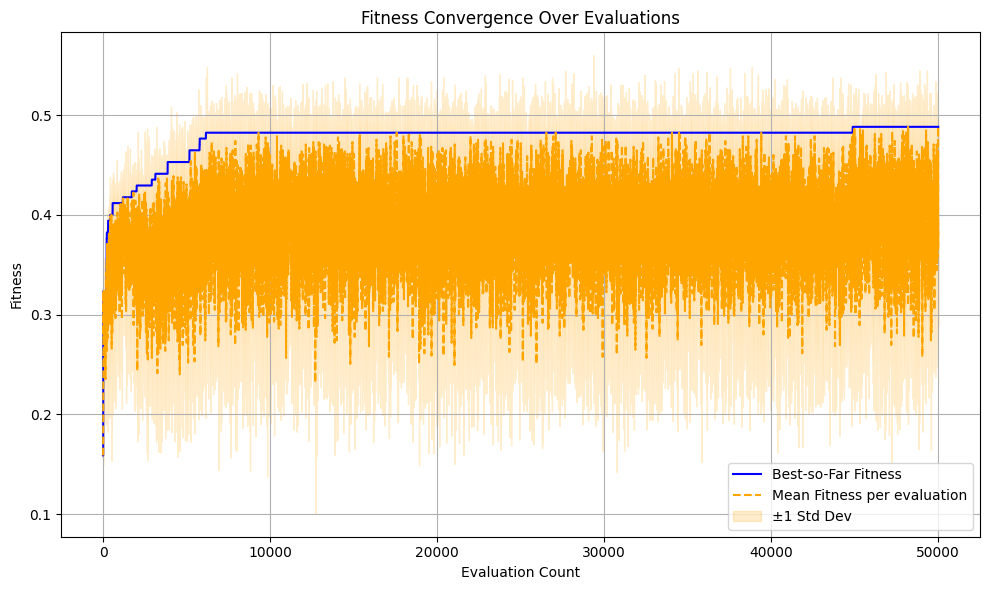

c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\pycgp_finalclass\Genome.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


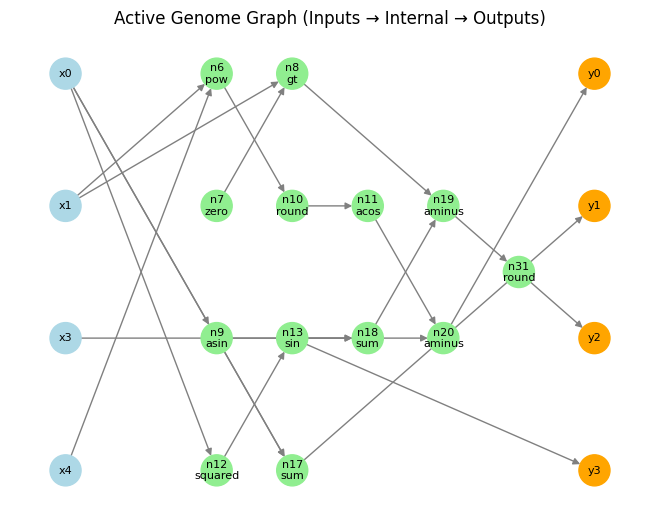

In [10]:

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Charger le fichier CSV avec le bon séparateur
file_path = 'datasets/Audio.xlsx'
df = pd.read_excel(file_path)

# Exemple : transformer les catégories d'âge en classes numériques
age_class_mapping = {
    '[18-25[': 0,
    '[25-35[': 1,
    '[35-45[': 2,
    '[45-55]': 3
}

# Appliquer la transformation
df['age_class_num'] = df['age_class'].map(age_class_mapping)

y = df['age_class_num']

# Supprimer les lignes NaN
mask = ~y.isna()
X = df.loc[mask, 'ampl':'plat_amp'].astype(float)
y = y[mask].astype(int)  # on garde int pour les classes

scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)



evaluator2 = MultiClassClassifier(X_scaled, y)

#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=4, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)
ES_cgp = ES(evaluator2, lam=5,parent = CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden)
best_genome = ES_cgp.evolve(n_generations=10000, early_stopping=10000, verbose=True)


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Charger le fichier CSV avec le bon séparateur
file_path = 'datasets/Audio.xlsx'
df = pd.read_excel(file_path)

# Exemple : transformer les catégories d'âge en classes numériques
age_class_mapping = {
    '[18-25[': 0,
    '[25-35[': 1,
    '[35-45[': 2,
    '[45-55]': 3
}

# Appliquer la transformation
df['age_class_num'] = df['age_class'].map(age_class_mapping)

y = df['age_class_num']

# Supprimer les lignes NaN
mask = ~y.isna()
X = df.loc[mask, 'ampl':'plat_amp'].astype(float)
y = y[mask].astype(int)  # on garde int pour les classes


# --- Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Optional: Standardize features for models that benefit from it (SVM, KNN, Ridge, etc.) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- Define classification models ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=100000),
    'Ridge Classifier': RidgeClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Classifier': SVC(),
    'KNN Classifier': KNeighborsClassifier()
}

# --- Evaluate accuracy for each model ---
results = {}

for name, model in models.items():
    if name in ['Support Vector Classifier', 'KNN Classifier', 'Ridge Classifier']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

# --- Show sorted results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
df_results = df_results.sort_values('Accuracy', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)


print("\n=== CGP result ===")
print(f"CGP: accuracy score = {evaluator2.evaluate(best_genome)}")


c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: Accuracy = 0.3471
Ridge Classifier: Accuracy = 0.3529
Random Forest: Accuracy = 0.3059
Gradient Boosting: Accuracy = 0.3294
Support Vector Classifier: Accuracy = 0.3412
KNN Classifier: Accuracy = 0.3000

=== Sorted Results ===
                           Accuracy
Ridge Classifier           0.352941
Logistic Regression        0.347059
Support Vector Classifier  0.341176
Gradient Boosting          0.329412
Random Forest              0.305882
KNN Classifier             0.300000

=== CGP result ===
CGP: accuracy score = 0.5591603053435115


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Charger le fichier CSV avec le bon séparateur
file_path = 'datasets/synth_table_anthr.csv'
df = pd.read_csv(file_path, sep=';')

# Exemple : transformer les catégories d'âge en classes numériques
sex_mapping = {
    'F': 0,
    'M': 1,
}

# Appliquer la transformation
df['sex_num'] = df['sex'].map(sex_mapping)

# Cible
y = df['sex_num']

# Sélection des colonnes freq0 à freq256
X = df.loc[:, 'f_max':'plat_amp'].astype(float)


# --- Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Optional: Standardize features for models that benefit from it (SVM, KNN, Ridge, etc.) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- Define classification models ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=100000),
    'Ridge Classifier': RidgeClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Classifier': SVC(),
    'KNN Classifier': KNeighborsClassifier()
}

# --- Evaluate accuracy for each model ---
results = {}

for name, model in models.items():
    if name in ['Support Vector Classifier', 'KNN Classifier', 'Ridge Classifier']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

# --- Show sorted results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
df_results = df_results.sort_values('Accuracy', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)


print("\n=== CGP result ===")
print(f"CGP: accuracy score = {evaluator2.evaluate(best_genome)}")


Logistic Regression: Accuracy = 0.6088
Ridge Classifier: Accuracy = 0.6107
Random Forest: Accuracy = 0.7691
Gradient Boosting: Accuracy = 0.6355
Support Vector Classifier: Accuracy = 0.5992
KNN Classifier: Accuracy = 0.6450

=== Sorted Results ===
                           Accuracy
Random Forest              0.769084
KNN Classifier             0.645038
Gradient Boosting          0.635496
Ridge Classifier           0.610687
Logistic Regression        0.608779
Support Vector Classifier  0.599237

=== CGP result ===
CGP: accuracy score = 0.5792899475853879


Starting fitness 0.4661


Gen 851 | Best: 0.5793: 100%|██████████| 1000/1000 [02:15<00:00,  7.38gen/s]



Best fitness achieved: 0.5793
n10 = sqrtxy(x8, x2)
n11 = mult(x6, x6)
n12 = aminus(n11, n10)
n13 = gt(x5, x2)
n14 = pow(n10, x8)
n15 = min(n14, x0)
n16 = sqrtxy(n10, n13)
n17 = min(x0, n12)
n18 = max(x9, n11)
n19 = gt(n18, x0)
n20 = sqrtxy(x1, n13)
n21 = pow(n14, n16)
n22 = round(x7)
n23 = squared(n22)
n24 = sqrt(n10)
n25 = sqrt(n18)
n26 = round(n17)
n27 = abs(n23)
n28 = inv(n22)
n29 = squared(n17)
n30 = aminus(n11, n18)
n31 = mult(x8, n11)
n32 = sqrt(x8)
n33 = pow(n18, n15)
n34 = one()
n35 = abs(n18)
n36 = aminus(x2, n11)
n37 = squared(n27)
n38 = exp(n36, n36)
n39 = sqrt(n30)
Outputs: n16

Unrolled output expression 0:
sqrtxy(sqrtxy(x8, x2), gt(x5, x2))



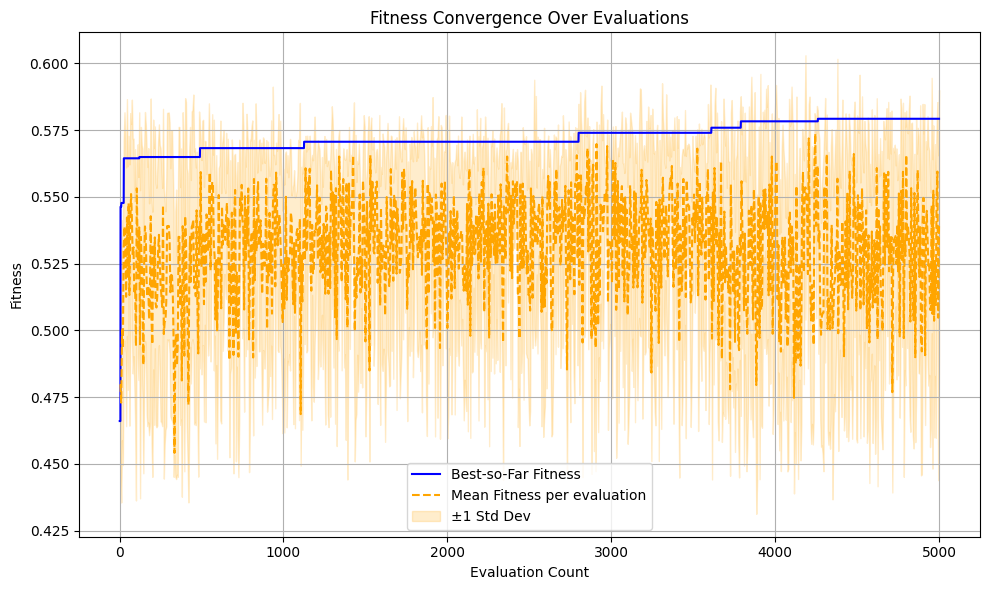

c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\pycgp_finalclass\Genome.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


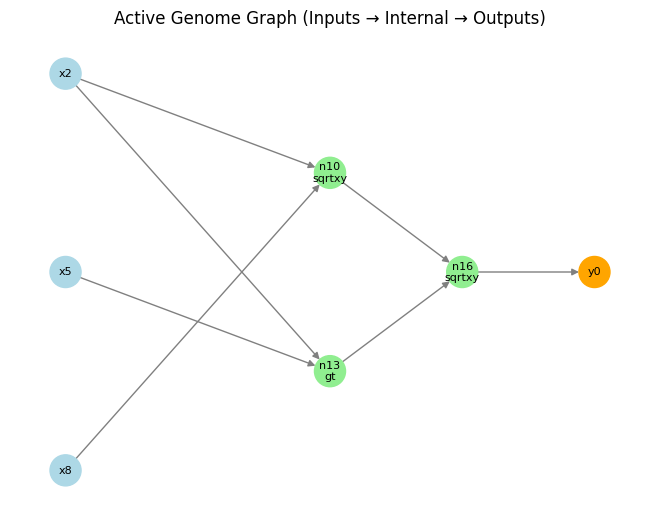

In [19]:

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Charger le fichier CSV avec le bon séparateur
file_path = 'datasets/synth_table_anthr.csv'
df = pd.read_csv(file_path, sep=';')

# Exemple : transformer les catégories d'âge en classes numériques
sex_mapping = {
    'F': 0,
    'M': 1,
}

# Appliquer la transformation
df['sex_num'] = df['sex'].map(sex_mapping)

# Cible
y = df['sex_num']

# Sélection des colonnes freq0 à freq256
X = df.loc[:, 'f_max':'plat_amp'].astype(float)


scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)



evaluator2 = Binary_Classifier(X_scaled, y,cv=True)

#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=1, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)
ES_cgp = ES(evaluator2, lam=5,parent = CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden)
best_genome = ES_cgp.evolve(n_generations=1000, early_stopping=1000, verbose=True)


In [ ]:

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Charger le fichier CSV avec le bon séparateur
file_path = 'datasets/synth_table_anthr.csv'
df = pd.read_csv(file_path, sep=';')


# Cible
y = df['age']

# Sélection des colonnes freq0 à freq256
X = df.loc[:, 'ampl':'mean_5000'].astype(float)
data = pd.concat([X, y], axis=1)
data_clean = data.dropna()
X = data_clean.drop(columns=['age'])
y = data_clean['age']


scaler = MinMaxScaler(feature_range=(-1,1))
X_scaled = scaler.fit_transform(X)

y = data_clean['age'].values.reshape(-1, 1)  # Reshape needed for scaler
y_scaler = MinMaxScaler(feature_range=(-1, 1))
y_scaled = y_scaler.fit_transform(y)
evaluator2 = Binary_Regressor(X_scaled, y_scaled, cv=False)

#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=1, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)
ES_cgp = ES(evaluator2, lam=5,parent = CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden)
best_genome = ES_cgp.evolve(n_generations=10000, early_stopping=10000, verbose=True, project_name= "age_classif")


Starting fitness -0.8473


Gen 2474 | Best: -0.0000:  34%|███▍      | 3432/10000 [08:22<16:02,  6.83gen/s]


KeyboardInterrupt: 

In [4]:
from pmlb import fetch_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import pandas as pd



# --- Split the dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Optional: Standardize features for models that benefit from it (SVM, KNN, Ridge, etc.) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Define regression models ---
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'KNN Regressor': KNeighborsRegressor()
}

# --- Evaluate R² for each model ---
results = {}

for name, model in models.items():
    if name in ['Support Vector Regressor', 'KNN Regressor', 'Ridge Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    results[name] = r2
    print(f"{name}: R² score = {r2:.4f}")

# --- Show sorted results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['R2 Score'])
df_results = df_results.sort_values('R2 Score', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)

print("\n=== CGP result ===")
print(f"CGP: R² score = {evaluator2.evaluate(best_genome)}")


Linear Regression: R² score = 0.0559
Ridge Regression: R² score = 0.0560
Random Forest: R² score = 0.3270
Gradient Boosting: R² score = 0.1564
Support Vector Regressor: R² score = 0.0902
KNN Regressor: R² score = 0.2675

=== Sorted Results ===
                          R2 Score
Random Forest             0.327017
KNN Regressor             0.267512
Gradient Boosting         0.156389
Support Vector Regressor  0.090206
Ridge Regression          0.056022
Linear Regression         0.055936

=== CGP result ===
CGP: R² score = 0.004850323025490155


In [ ]:
# add mean to the graph and standard deviation ## redo with mean per run
# rescale to fit range of the age (to see cause 18-55 seems to not give good results)
# Changing the library of function to fit the problem (removed some functions that were not suited to age regression)
#compare to other methods (perform not so bad compare to other methods, particularly for sex classification)
#Try to break the unit test
#Test with raw data and refined data on multiple instances and compare the results
#Add save for results (txt or csv) #DONE
#Try to restart the evolution process after a certain number of generations from scratch #Normally done, still need some tests 
# try refine of inputs and functions during the evolution process (even others parameters)
#Try to see the distribution of features over time 
# Corellation between features
# Try to use a mask on regressor to see if the prediction fit a certain range around the real value.

In [ ]:
# try refine of inputs and functions during the evolution process (need to talk to yuri about it)

#Entretien Patricia:

# Tri des données problématiques, retirer population avec trop de bruit, retirer colonne trop peu renseignées, retirer colonne qui se répete
# Faire des tests sur les population avec les échantillons les plus clean (toulouse)
# Faire de nouvelles mesures audios (hugo)
# Arrivée des genetes en Septembre
# Pour le moment prendre seulement les groupe de langue, attendre les avancées du linguiste pour les classifier.
# Demander à sylvain ce qu'il pense des clusters de profils audio

# Pour Papier de recherche:

#Comparer CGP avec GP et d'autres ML et Neural Networks
# Compare to reliefF method
